In [1]:
! pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 16.5 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.5 MB/s eta 0:00:00


In [2]:
from fastbook import *
from fastai.vision.all import *

In [3]:
# download pet breeds dataset
path = untar_data(URLs.PETS)
path.ls()

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:15&lt;00:00]</div>

[Path('/root/.fastai/data/oxford-iiit-pet/images'), Path('/root/.fastai/data/oxford-iiit-pet/annotations')]

In [4]:
Path.BASE_PATH = path
path.ls()

[Path('images'), Path('annotations')]

In [5]:
(path/'annotations').ls()

[Path('annotations/xmls'), Path('annotations/README'), Path('annotations/._trimaps'), Path('annotations/list.txt'), Path('annotations/test.txt'), Path('annotations/trainval.txt'), Path('annotations/trimaps')]

`annotations/` contains location data that we don't need, so we'll focus on `images/`

In [6]:
!ls {path/'images'}

Abyssinian_100.jpg		   keeshond_186.jpg
Abyssinian_100.mat		   keeshond_187.jpg
Abyssinian_101.jpg		   keeshond_188.jpg
Abyssinian_101.mat		   keeshond_189.jpg
Abyssinian_102.jpg		   keeshond_18.jpg
Abyssinian_102.mat		   keeshond_190.jpg
Abyssinian_103.jpg		   keeshond_191.jpg
Abyssinian_104.jpg		   keeshond_192.jpg
Abyssinian_105.jpg		   keeshond_193.jpg
Abyssinian_106.jpg		   keeshond_194.jpg
Abyssinian_107.jpg		   keeshond_195.jpg
Abyssinian_108.jpg		   keeshond_196.jpg
Abyssinian_109.jpg		   keeshond_197.jpg
Abyssinian_10.jpg		   keeshond_198.jpg
Abyssinian_110.jpg		   keeshond_199.jpg
Abyssinian_111.jpg		   keeshond_19.jpg
Abyssinian_112.jpg		   keeshond_1.jpg
Abyssinian_113.jpg		   keeshond_200.jpg
Abyssinian_114.jpg		   keeshond_20.jpg
Abyssinian_115.jpg		   keeshond_21.jpg
Abyssinian_116.jpg		   keeshond_22.jpg
Abyssinian_117.jpg		   keeshond_23.jpg
Abyssinian_118.jpg		   keeshond_24.jpg
Abyssinian_119.jpg		   keeshond_25.jpg
Abyssinian_11.jpg		   keeshond_26.jpg
Abyssinian_12

In [7]:
len((path/'images').ls())

7393

Need to get labels from the file names.

In [8]:
fname = (path/'images').ls()[0]

In [9]:
fname

Path('images/beagle_115.jpg')

In [10]:
re.findall(r'(.+)_\d+.jpg$', fname.name)

['beagle']

In [11]:
pets = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(seed=42),
                 get_y=using_attr(RegexLabeller(r'(.+)_\d+.jpg$'), 'name'),
                 item_tfms=Resize(460),
                 batch_tfms=aug_transforms(size=224, min_scale=0.75))
dls = pets.dataloaders(path/"images")

pets, dls

(<fastai.data.block.DataBlock at 0x7a5e70f7e720>,
 <fastai.data.core.DataLoaders at 0x7a5e713fe630>)

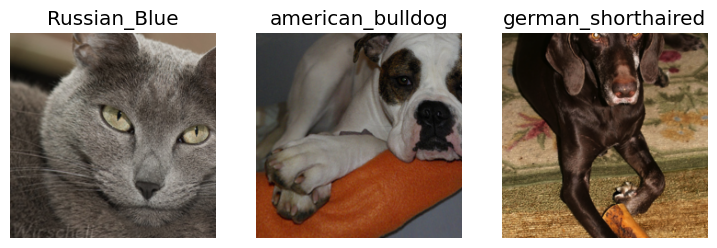

In [12]:
dls.show_batch(nrows=1, ncols=3)

In [13]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(2)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 166MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,1.520345,0.370408,0.118403,00:34


epoch,train_loss,valid_loss,error_rate,time
0,0.481533,0.301554,0.094046,00:41
1,0.306911,0.216866,0.067659,00:43


In [14]:
x, y = dls.one_batch()
y

TensorCategory([27,  9,  8,  6,  2, 27,  9, 28, 26, 18, 19, 17, 12,  3, 21,  5, 20, 29, 22, 26, 15, 33,  8, 22, 25, 24, 11,  4, 21, 24, 21,  6, 22, 29,  7, 35, 16, 16,  1,  3, 25, 22,  7,  9, 29, 26,
                26, 30,  0, 29, 16,  1,  0, 18, 18, 36, 26, 18, 36, 35, 18, 28, 11,  9], device='cuda:0')

In [15]:
y.shape

torch.Size([64])

In [16]:
preds,_ = learn.get_preds(dl=[(x,y)])
preds.shape

torch.Size([64, 37])

In [17]:
preds[0], preds[0].shape, preds[0].sum()

(tensor([7.0221e-09, 3.7355e-10, 1.3444e-07, 3.4544e-09, 1.9314e-06, 1.6774e-08, 1.1856e-06, 3.6337e-07, 9.0114e-10, 8.7977e-08, 8.8092e-09, 2.5029e-09, 1.3432e-08, 8.9883e-08, 8.6018e-08, 3.9465e-09,
         1.5409e-08, 2.1996e-09, 2.2745e-07, 1.9648e-09, 7.7062e-07, 2.9116e-05, 9.9350e-07, 7.2160e-07, 3.2417e-07, 7.0229e-05, 1.5290e-08, 9.9989e-01, 6.4986e-07, 1.7567e-07, 1.6348e-06, 1.0127e-07,
         5.0735e-08, 3.6747e-09, 4.8722e-09, 4.5935e-07, 2.5893e-09]),
 torch.Size([37]),
 tensor(1.0000))

In [18]:
torch.random.manual_seed(42)

In [19]:
acts = torch.randn((6,2)) * 2
acts

tensor([[ 0.6734,  0.2576],
        [ 0.4689,  0.4607],
        [-2.2457, -0.3727],
        [ 4.4164, -1.2760],
        [ 0.9233,  0.5347],
        [ 1.0698,  1.6187]])

In [20]:
acts.sigmoid()

tensor([[0.6623, 0.5641],
        [0.6151, 0.6132],
        [0.0957, 0.4079],
        [0.9881, 0.2182],
        [0.7157, 0.6306],
        [0.7446, 0.8346]])

In [21]:
(acts[:,0]-acts[:,1]).sigmoid()

tensor([0.6025, 0.5021, 0.1332, 0.9966, 0.5959, 0.3661])

In [22]:
sm_acts = torch.softmax(acts, dim=1)
sm_acts

tensor([[0.6025, 0.3975],
        [0.5021, 0.4979],
        [0.1332, 0.8668],
        [0.9966, 0.0034],
        [0.5959, 0.4041],
        [0.3661, 0.6339]])

In [23]:
targ = tensor([0,1,0,1,1,0])

In [24]:
idx = range(6)
sm_acts[idx, targ]

tensor([0.6025, 0.4979, 0.1332, 0.0034, 0.4041, 0.3661])

In [27]:
from IPython.display import HTML
df = pd.DataFrame(sm_acts, columns=["3","7"])
df['targ'] = targ
df['idx'] = idx
df['result'] = sm_acts[range(6), targ]
t = df.style.hide(axis="index")
#To have html code compatible with our script
html = t._repr_html_()
html = re.sub(r'<style[^<]*<\/style>', '', html)  # optional: strip styles
display(HTML(html))

3,7,targ,idx,result
0.602469,0.397531,0,0,0.602469
0.502065,0.497935,1,1,0.497935
0.133188,0.866811,0,2,0.133188
0.996640,0.003360,1,3,0.003360
0.595949,0.404051,1,4,0.404051
0.366118,0.633882,0,5,0.366118


In [29]:
-sm_acts[idx, targ]

tensor([-0.6025, -0.4979, -0.1332, -0.0034, -0.4041, -0.3661])

In [30]:
F.nll_loss(sm_acts, targ, reduction='none')

tensor([-0.6025, -0.4979, -0.1332, -0.0034, -0.4041, -0.3661])